توضیح پروژه: تحلیل روند ریسک و سودآوری شرکت‌های بورسی ایران (۱۳۹۴–۱۴۰۱)
این پروژه با هدف بررسی وضعیت ریسک و سودآوری ۶۰ شرکت بورسی در بازه زمانی سال‌های ۱۳۹۴ تا ۱۴۰۱ طراحی شده است. داده‌ها از صورت‌های مالی حسابرسی‌شده استخراج شده و شامل شاخص‌های کلیدی مانند نسبت بدهی به حقوق صاحبان سهام، نسبت جاری، بازده دارایی‌ها، بازده حقوق صاحبان سهام، حاشیه سود خالص، حاشیه سود عملیاتی و گردش دارایی می‌باشد.

در این مطالعه ابتدا داده‌ها نرمال‌سازی شده و با استفاده از میانگین وزنی، امتیاز ریسک هر شرکت محاسبه شده است. سپس برای تحلیل دقیق‌تر روابط میان ریسک، نقدینگی و دارایی‌ها با سود قبل از مالیات، مدل منطق فازی طراحی و اجرا گردیده است.

هدف اصلی این پژوهش، ارائه چارچوبی ترکیبی از روش‌های کمی (امتیازدهی عددی) و کیفی (منطق فازی) برای پیش‌بینی و تحلیل سودآوری شرکت‌ها است. نتایج نشان می‌دهد اکثر شرکت‌ها در محدوده ریسک متوسط تا پایین قرار دارند و مدل فازی توانسته است پیش‌بینی سودآوری را بهبود دهد

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
file_path = '/content/drive/My Drive/Zahra/IranStockExchange.xlsx'
df = pd.read_excel(file_path)
print(df.head())

Mounted at /content/drive
   ID       Firm  Year     Industry Symbol    Cash  Short term investment  \
0   1  البرزدارو  1394  مواد دارویی  دالبر   24669                      0   
1   1  البرزدارو  1395  مواد دارویی  دالبر  182875                      0   
2   1  البرزدارو  1396  مواد دارویی  دالبر   22583                      0   
3   1  البرزدارو  1397  مواد دارویی  دالبر  212555                      0   
4   1  البرزدارو  1398  مواد دارویی  دالبر  174887                      0   

   Tangible fixed assets  Current asset  Total assets  Current debt     debt  \
0                 271878        2555666       2852280       1147932  1159477   
1                 330917        3477074       3914815       1634294  1648153   
2                 468898        4806150       5284110       2531974  2551332   
3                 909434        6862026       8361010       4409486  4440731   
4                1065818        9237503      10905214       5462191  5489459   

        sale     tax  Profit b

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 18 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         1040 non-null   int64  
 1   Firm                                       1040 non-null   object 
 2   Year                                       1040 non-null   int64  
 3    Industry                                  1040 non-null   object 
 4   Symbol                                     1040 non-null   object 
 5   Cash                                       1040 non-null   int64  
 6   Short term investment                      1040 non-null   int64  
 7   Tangible fixed assets                      1040 non-null   int64  
 8   Current asset                              1040 non-null   int64  
 9   Total assets                               1040 non-null   int64  
 10  Current debt            

In [ ]:
print(df.shape)

(1040, 18)


In [ ]:
import pandas as pd

file_path = "/content/drive/My Drive/Zahra/IranStockExchange.xlsx"
sheet     = "Sheet1"

df = pd.read_excel(file_path, sheet_name=sheet)

numeric_cols = ['Cash', 'Short term investment', 'Short term investment',
                'Current asset', 'Total assets', 'Current debt', 'debt', 'sale',
                'tax', 'Profit before tax', 'net profit',
                'Operating cash flows for the current year']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if {'Current asset','Current debt'}.issubset(df.columns):
    df['current_ratio'] = df['Current asset'] / df['Current debt']

if {'debt','Total assets'}.issubset(df.columns):
    df['debt_to_equity'] = df['debt'] / (df['Total assets'] - df['debt'])

if {'net profit','sale'}.issubset(df.columns):
    df['net_profit_margin'] = df['net profit'] / df['sale']
    df['return_on_assets']  = df['net profit'] / df['Total assets']
    df['return_on_equity']  = df['net profit'] / (df['Total assets'] - df['debt'])

if {'tax','sale'}.issubset(df.columns):
    df['gross_margin'] = df['tax'] / df['sale']

if {'Profit before tax','sale'}.issubset(df.columns):
    df['operating_margin'] = df['Profit before tax'] / df['sale']

if {'sale','Total assets'}.issubset(df.columns):
    df['asset_turnover'] = df['sale'] / df['Total assets']

if {'Operating cash flows for the current year','debt'}.issubset(df.columns):
    df['cashflow_to_debt'] = df['Operating cash flows for the current year'] / df['debt']

df.to_csv("financial_ratios.csv", index=False)
print("Saved financial_ratios.csv")

Saved financial_ratios.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
file_path = '/content/drive/My Drive/Zahra/financial_ratios.csv'
df = pd.read_csv(file_path)
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ID       Firm  Year     Industry Symbol    Cash  Short term investment  \
0   1  البرزدارو  1394  مواد دارویی  دالبر   24669                      0   
1   1  البرزدارو  1395  مواد دارویی  دالبر  182875                      0   
2   1  البرزدارو  1396  مواد دارویی  دالبر   22583                      0   
3   1  البرزدارو  1397  مواد دارویی  دالبر  212555                      0   
4   1  البرزدارو  1398  مواد دارویی  دالبر  174887                      0   

   Tangible fixed assets  Current asset  Total assets  ...  Tax paid  \
0                 271878        2555666       2852280  ...    183869   
1                 330917        3477074       3914815  ...    241174   
2                 468898        4806150       5284110  ...    311956   
3                 909434        6862026       8361010  ...    363310   
4                1065818        9237503      109

In [ ]:
df.describe()

,ID,Year,Cash,Short term investment,Tangible fixed assets,Current asset,Total assets,Current debt,debt,sale,...,Tax paid,Operating cash flows for the current year,current_ratio,debt_to_equity,net_profit_margin,return_on_assets,return_on_equity,gross_margin,operating_margin,asset_turnover
count,1040.000000,1040.00000,1.040000e+03,1.040000e+03,1.040000e+03,1.040000e+03,1.040000e+03,1.040000e+03,1.040000e+03,1.040000e+03,...,1.040000e+03,1.040000e+03,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000
mean,65.500000,1397.50000,9.640865e+05,1.008441e+06,4.113559e+06,1.345892e+07,2.254839e+07,1.255403e+07,1.377524e+07,1.930824e+07,...,2.385098e+05,2.626115e+06,1.828952,1.713872,0.202353,0.147596,0.245667,0.024355,0.226708,0.947213
std,37.544712,2.29239,6.141317e+06,9.131345e+06,1.722180e+07,7.932620e+07,1.179232e+08,7.163973e+07,7.633622e+07,1.069338e+08,...,2.019055e+06,2.027197e+07,1.761772,7.402635,0.391692,0.158210,1.600409,0.028613,0.400647,0.605431
min,1.000000,1394.00000,4.370000e+02,0.000000e+00,9.736000e+03,3.224100e+04,7.296000e+04,1.190500e+04,1.640400e+04,1.674600e+04,...,0.000000e+00,-2.489394e+07,0.214718,-63.434612,-3.424832,-0.562895,-46.073992,0.000000,-3.424832,0.039308
25%,33.000000,1395.75000,2.647075e+04,0.000000e+00,2.282285e+05,8.260250e+05,1.345460e+06,5.374915e+05,6.365918e+05,1.038807e+06,...,4.474750e+03,4.445750e+04,1.111152,0.567638,0.041437,0.037544,0.104486,0.001584,0.049982,0.550420
50%,65.500000,1397.50000,9.904100e+04,2.600000e+02,5.695210e+05,2.075214e+06,3.116644e+06,1.425736e+06,1.625502e+06,2.519894e+06,...,2.651100e+04,2.492125e+05,1.437257,1.115218,0.145012,0.119826,0.296035,0.016642,0.170507,0.797762
75%,98.000000,1399.25000,3.303768e+05,5.463325e+04,1.671301e+06,5.706501e+06,9.168241e+06,3.913614e+06,4.472968e+06,7.388124e+06,...,8.853350e+04,8.872260e+05,1.980150,2.104276,0.310899,0.241359,0.510203,0.036078,0.348394,1.198534
max,130.000000,1401.00000,1.100532e+08,2.008178e+08,2.662953e+08,1.682738e+09,2.335883e+09,1.251650e+09,1.309065e+09,1.881503e+09,...,4.481599e+07,4.280329e+08,27.095449,195.018454,7.802988,0.681977,3.573006,0.342174,7.837376,5.776184


In [ ]:
"""
classify_company_risk_p75.py
----------------------------
طبقه‌بندی شرکت‌های بورسی بر اساس Debt-to-Equity با آستانهٔ صدک ۷۵:
    - High-Risk : debt_to_equity > 75th percentile
    - Low-Risk  : debt_to_equity ≤ 75th percentile
"""

import pandas as pd
from pathlib import Path

csv_path = Path("/content/drive/My Drive/Zahra/financial_ratios.csv")
sheet_name = "Sheet4"


df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

for col in ['debt', 'Total assets']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

p75_threshold = df['debt_to_equity'].quantile(0.75, interpolation="midpoint")
print(f"↳ آستانهٔ دینامیک (صدک ۷۵ D/E): {p75_threshold:0.3f}")

df['risk_class'] = (df['debt_to_equity'] > p75_threshold) \
                   .map({True: 'High-Risk', False: 'Low-Risk'})

print("\n=== تعداد شرکت‌ها در هر کلاس ریسک ===")
print(df['risk_class'].value_counts(dropna=False))

out_file = Path("companies_risk_class_p75.csv")
df.to_csv(out_file, index=False)
print(f"\nنتیجه در «{out_file}» ذخیره شد.")

↳ آستانهٔ دینامیک (صدک ۷۵ D/E): 2.107

=== تعداد شرکت‌ها در هر کلاس ریسک ===
risk_class
Low-Risk     780
High-Risk    260
Name: count, dtype: int64

نتیجه در «companies_risk_class_p75.csv» ذخیره شد.


In [ ]:
import pandas as pd
from pathlib import Path
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

csv_path = Path("/content/drive/My Drive/Zahra/financial_ratios.csv")

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

for col in ['debt', 'Total assets']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'debt_to_equity' not in df.columns:
    df['debt_to_equity'] = df['debt'] / (df['Total assets'] - df['debt'])

df = df.dropna(subset=['debt_to_equity'])

p75_threshold = df['debt_to_equity'].quantile(0.75, interpolation="midpoint")
print(f" آستانهٔ  (صدک ۷۵ D/E): {p75_threshold:.3f}")

# ایجاد ستون لیبل صفر و یک (کم ریسک=0، پرریسک=1)
df['risk_label'] = (df['debt_to_equity'] > p75_threshold).astype(int)

print("\n=== تعداد شرکت‌ها در هر کلاس ریسک ===")
print(df['risk_label'].value_counts())

# انتخاب ویژگی‌ها برای مدل (می‌توانید ستون‌های آماری بیشتر اضافه کنید)
features = ['debt_to_equity']

X = df[features].fillna(0)
y = df['risk_label']

# مقیاس‌بندی ویژگی‌ها (ضروری برای SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

svm_model = SVC(kernel='rbf', C=1, gamma='scale')

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

out_file = Path("companies_risk_class_p75_with_label.csv")
df.to_csv(out_file, index=False)
print(f"\nنتیجه با ستون لیبل در «{out_file}» ذخیره شد.")


 آستانهٔ  (صدک ۷۵ D/E): 2.107

=== تعداد شرکت‌ها در هر کلاس ریسک ===
risk_label
0    780
1    260
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       146
           1       1.00      0.87      0.93        62

    accuracy                           0.96       208
   macro avg       0.97      0.94      0.95       208
weighted avg       0.96      0.96      0.96       208

Confusion Matrix:
[[146   0]
 [  8  54]]

نتیجه با ستون لیبل در «companies_risk_class_p75_with_label.csv» ذخیره شد.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report
# دقت کل مدل
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy (دقت کل مدل): {accuracy:.4f}')

Accuracy (دقت کل مدل): 0.9615


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# فرض: داده df آماده است، ستون ویژگی‌ها X و هدف y تعریف شده‌اند

X = df[features].fillna(0)
y = df['risk_label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# محاسبه وزن کلاس‌ها برای مقابله با عدم تعادل
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {cls: weight for cls, weight in zip(classes, class_weights)}
print(f"وزن‌های کلاس‌ها: {class_weight_dict}")

svm_model = SVC(kernel='rbf', C=1, gamma='scale', class_weight=class_weight_dict, probability=True)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]  # احتمال پیش‌بینی کلاس 1

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# تنظیم آستانه تصمیم (برای افزایش Recall)
threshold = 0.3  # مثلا کمتر از 0.5 که موجب حساسیت بالاتر می‌شود
y_pred_threshold = (y_prob >= threshold).astype(int)

print(f"\nگزارش با آستانه تصمیم {threshold}:")
print(classification_report(y_test, y_pred_threshold))
print("ماتریس سردرگمی با آستانه تصمیم جدید:")
print(confusion_matrix(y_test, y_pred_threshold))

وزن‌های کلاس‌ها: {np.int64(0): np.float64(0.6666666666666666), np.int64(1): np.float64(2.0)}
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       156
           1       0.95      1.00      0.97        52

    accuracy                           0.99       208
   macro avg       0.97      0.99      0.98       208
weighted avg       0.99      0.99      0.99       208

Confusion Matrix:
[[153   3]
 [  0  52]]

گزارش با آستانه تصمیم 0.3:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       156
           1       0.98      1.00      0.99        52

    accuracy                           1.00       208
   macro avg       0.99      1.00      0.99       208
weighted avg       1.00      1.00      1.00       208

ماتریس سردرگمی با آستانه تصمیم جدید:
[[155   1]
 [  0  52]]


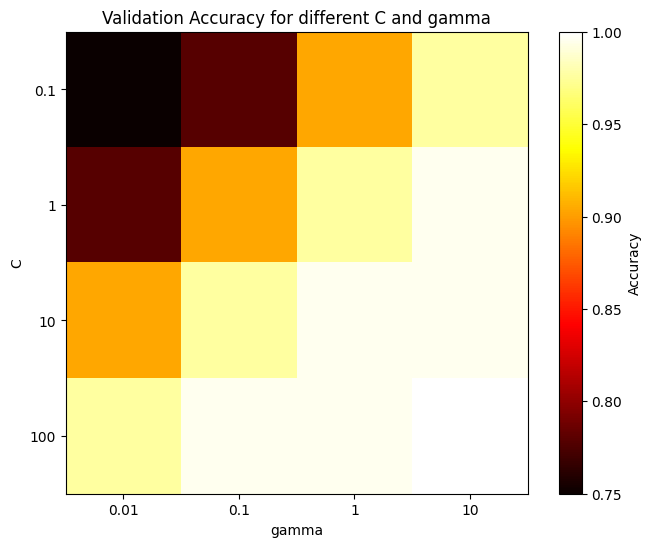

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

C_range = [0.1, 1, 10, 100]
gamma_range = [0.01, 0.1, 1, 10]

# ماتریس دقت را برای ترکیب های پارامترها
scores = np.zeros((len(C_range), len(gamma_range)))

# حلقه روی پارامترها و آموزش مدل و محاسبه دقت
for i, C in enumerate(C_range):
    for j, gamma in enumerate(gamma_range):
        model = SVC(kernel='rbf', C=C, gamma=gamma)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        scores[i, j] = accuracy_score(y_val, y_pred)

# رسم Heatmap دقت
plt.figure(figsize=(8, 6))
plt.imshow(scores, interpolation='nearest', cmap=plt.cm.hot)
plt.xlabel('gamma')
plt.ylabel('C')
plt.colorbar(label='Accuracy')
plt.xticks(np.arange(len(gamma_range)), gamma_range)
plt.yticks(np.arange(len(C_range)), C_range)
plt.title('Validation Accuracy for different C and gamma')
plt.show()


<Figure size 1000x700 with 0 Axes>

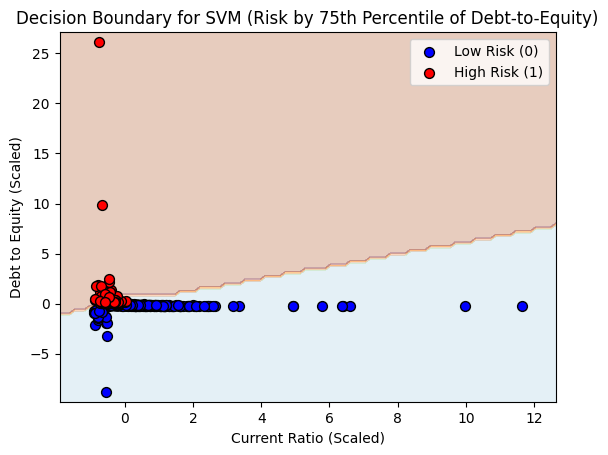

In [ ]:
import pandas as pd
from pathlib import Path
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt
import numpy as np

csv_path = Path("/content/drive/My Drive/Zahra/financial_ratios.csv")

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

for col in ['current_ratio', 'debt_to_equity']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ساخت ستون برچسب بر اساس صدک ۷۵ debt_to_equity
p75 = df['debt_to_equity'].quantile(0.75, interpolation="midpoint")
df['risk_label'] = (df['debt_to_equity'] > p75).astype(int)

df = df.dropna(subset=['current_ratio', 'debt_to_equity', 'risk_label'])

# انتخاب ویژگی‌ها و هدف
features = ['current_ratio', 'debt_to_equity']
X = df[features].values
y = df['risk_label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

svm_model = SVC(kernel='poly', class_weight='balanced')
svm_model.fit(X_train, y_train)

# رسم مرز تصمیم
plt.figure(figsize=(10, 7))
disp = DecisionBoundaryDisplay.from_estimator(
    svm_model,
    X_train,
    response_method='predict',
    alpha=0.3,
    cmap=plt.cm.Paired,
    xlabel='Current Ratio (Scaled)',
    ylabel='Debt to Equity (Scaled)'
)

colors = ['blue', 'red']
labels = ['Low Risk (0)', 'High Risk (1)']
for idx, label in enumerate(np.unique(y_train)):
    plt.scatter(
        X_train[y_train == label, 0],
        X_train[y_train == label, 1],
        c=colors[idx],
        label=labels[idx],
        edgecolors='k',
        s=50
    )
plt.title('Decision Boundary for SVM (Risk by 75th Percentile of Debt-to-Equity)')
plt.legend()
plt.show()

## پس از اینکه دقت مدل قبلی که به دو دسته کم ریسک و پر ریسک  طبقه بندی می کرد  بررسی شد و مدل طبقه بندی آن بهبود پیدا کرد حال به سراغ امتیاز دهی عددی خواهیم رفت بخشی که در مقاله ما مورد توجه است و قرار است از آن در منطق فازی به عنوان یک ورودی مهم استفاده **کنیم**

# امتیاز دهی بر اساس  ریسک شرکت ها

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
risk_features = [
    'debt_to_equity',
    'current_ratio',
    'return_on_assets',
    'return_on_equity',
    'net_profit_margin',
    'operating_margin',
    'asset_turnover'
]

df_clean = df[risk_features].dropna().copy()

## نرمال سازی

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(df_clean)

# تبدیل به DataFrame با همان نام ستون‌ها
norm_df = pd.DataFrame(normalized_features, columns=risk_features)

In [ ]:
import numpy as np

weights = np.full(len(risk_features), 1 / len(risk_features))  # وزن برابر برای همه ویژگی‌ها
# محاسبه Risk Score
df_clean['risk_score'] = np.dot(norm_df, weights)

df_result = df.loc[df_clean.index].copy()
df_result['risk_score'] = df_clean['risk_score']

In [ ]:
df_result['risk_level'] = pd.qcut(df_result['risk_score'], q=3, labels=['Low', 'Medium', 'High'])

print(df_result['risk_level'].value_counts())

risk_level
Low       347
High      347
Medium    346
Name: count, dtype: int64


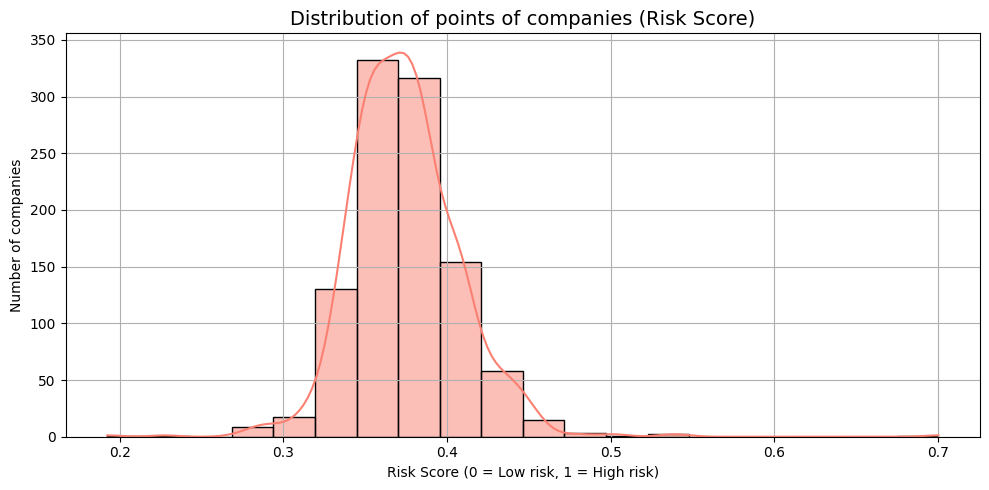

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(df_result['risk_score'], bins=20, kde=True, color='salmon')
plt.title("Distribution of points of companies (Risk Score)", fontsize=14)
plt.xlabel("Risk Score (0 = Low risk, 1 = High risk)")
plt.ylabel("Number of companies")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
df_result[['Firm', 'Year', 'risk_score', 'risk_level']].head(20)

,Firm,Year,risk_score,risk_level
0,البرزدارو,1394,0.401370,High
1,البرزدارو,1395,0.395073,High
2,البرزدارو,1396,0.384835,Medium
3,البرزدارو,1397,0.371260,Medium
4,البرزدارو,1398,0.380866,Medium
5,البرزدارو,1399,0.378889,Medium
6,البرزدارو,1400,0.376823,Medium
7,البرزدارو,1401,0.381119,Medium
8,اما,1394,0.372808,Medium
9,اما,1395,0.381875,Medium


سال‌های ۱۳۹۴ و ۱۳۹۵، هر کدام ۲ بار در دیتافریم ظاهر شدند

بقیه سال‌ها (۱۳۹۶ تا ۱۴۰۱) هرکدام فقط یک بار وجود دارند

In [ ]:
df_result.to_csv("final_risk_scored_companies.csv", index=False)

## نمودار های بخش زیر حتما در مقاله آورده شود

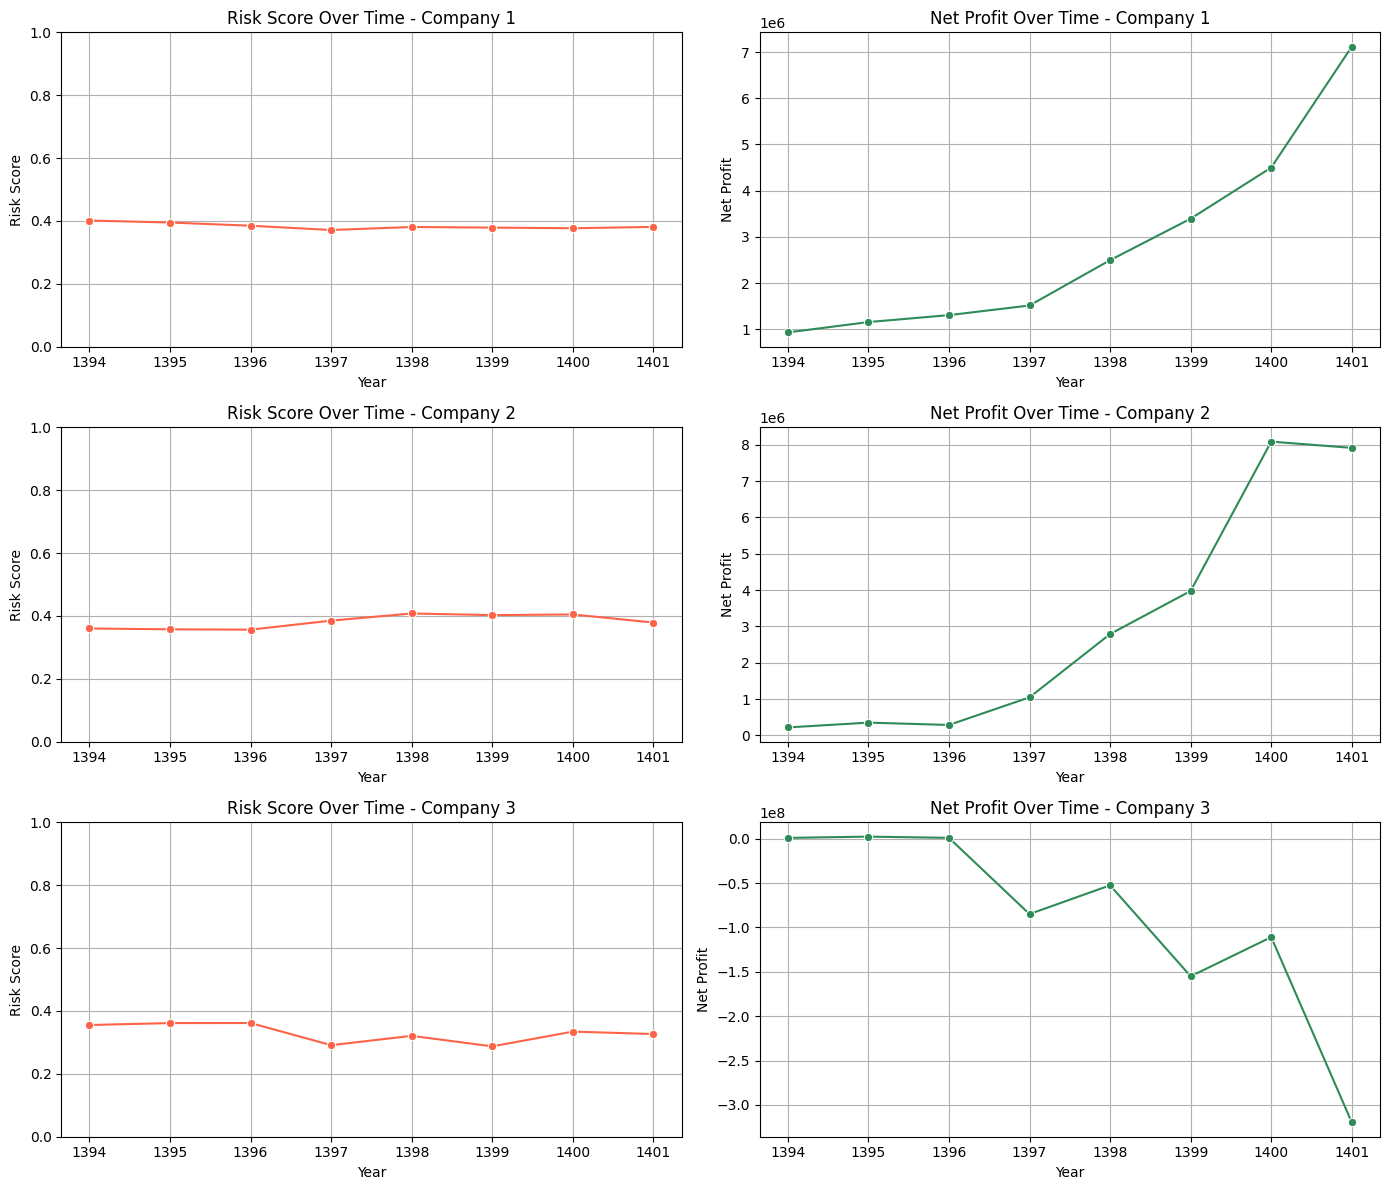

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/financial_ratios.csv")
df.columns = df.columns.str.strip()

raw_df = pd.read_excel("/content/drive/My Drive/Zahra/IranStockExchange.xlsx", sheet_name="Sheet1")
raw_df.columns = raw_df.columns.str.strip()

risk_features = [
    'debt_to_equity', 'current_ratio', 'return_on_assets',
    'return_on_equity', 'net_profit_margin',
    'operating_margin', 'asset_turnover'
]

df_clean = df[risk_features].dropna().copy()
scaler = MinMaxScaler()
normalized = scaler.fit_transform(df_clean)
norm_df = pd.DataFrame(normalized, columns=risk_features)
weights = np.full(len(risk_features), 1 / len(risk_features))
df_clean['risk_score'] = np.dot(norm_df, weights)

df_result = df.loc[df_clean.index].copy()
df_result['risk_score'] = df_clean['risk_score']
df_result['risk_level'] = pd.qcut(df_result['risk_score'], q=3, labels=['Low', 'Medium', 'High'])

profit_df = raw_df[['Firm', 'Year', 'net profit']].copy()
profit_df.columns = ['Firm', 'Year', 'net_profit']
merged_df = pd.merge(df_result, profit_df, on=['Firm', 'Year'], how='inner')

company_map = {
    'البرزدارو': 'Company 1',
    'دارو اکسیر': 'Company 2',
    'ایران خودرو': 'Company 3'
}

companies = list(company_map.keys())

plt.figure(figsize=(14, len(companies) * 4))

for i, company_fa in enumerate(companies):
    company_en = company_map[company_fa]
    company_df = merged_df[merged_df['Firm'] == company_fa].sort_values('Year')

    # Risk Score plot
    plt.subplot(len(companies), 2, 2*i+1)
    sns.lineplot(data=company_df, x='Year', y='risk_score', marker='o', color='tomato')
    plt.title(f'Risk Score Over Time - {company_en}', fontsize=12)
    plt.xlabel("Year")
    plt.ylabel("Risk Score")
    plt.ylim(0, 1)
    plt.grid(True)

    # Net Profit plot
    plt.subplot(len(companies), 2, 2*i+2)
    sns.lineplot(data=company_df, x='Year', y='net_profit', marker='o', color='seagreen')
    plt.title(f'Net Profit Over Time - {company_en}', fontsize=12)
    plt.xlabel("Year")
    plt.ylabel("Net Profit")
    plt.grid(True)

plt.tight_layout()
plt.show()


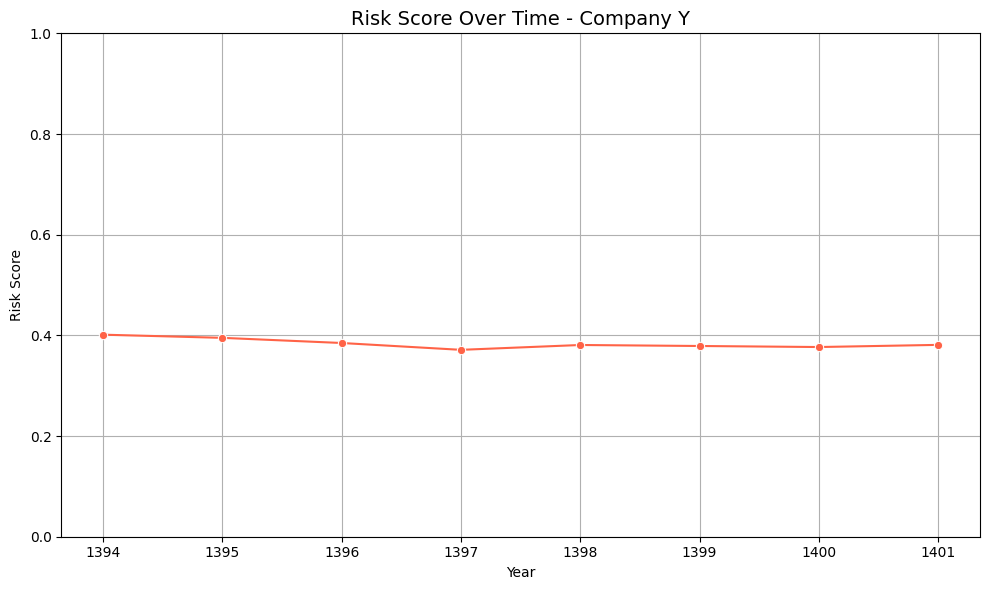

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# بارگذاری داده‌ها
df = pd.read_csv("/content/financial_ratios.csv")
df.columns = df.columns.str.strip()
raw_df = pd.read_excel("/content/drive/My Drive/Zahra/IranStockExchange.xlsx", sheet_name="Sheet1")
raw_df.columns = raw_df.columns.str.strip()

# محاسبه امتیاز ریسک
risk_features = [
    'debt_to_equity', 'current_ratio', 'return_on_assets',
    'return_on_equity', 'net_profit_margin',
    'operating_margin', 'asset_turnover'
]

df_clean = df[risk_features].dropna().copy()
scaler = MinMaxScaler()
normalized = scaler.fit_transform(df_clean)
norm_df = pd.DataFrame(normalized, columns=risk_features)
weights = np.full(len(risk_features), 1 / len(risk_features))
df_clean['risk_score'] = np.dot(norm_df, weights)

df_result = df.loc[df_clean.index].copy()
df_result['risk_score'] = df_clean['risk_score']
df_result['risk_level'] = pd.qcut(df_result['risk_score'], q=3, labels=['Low', 'Medium', 'High'])

profit_df = raw_df[['Firm', 'Year', 'net profit']].copy()
profit_df.columns = ['Firm', 'Year', 'net_profit']
merged_df = pd.merge(df_result, profit_df, on=['Firm', 'Year'], how='inner')

# نمودار ۱: روند امتیاز ریسک شرکت البرزدارو
company_fa = 'البرزدارو'
company_en = 'Company Y'
company_df = merged_df[merged_df['Firm'] == company_fa].sort_values('Year')

plt.figure(figsize=(10, 6))
sns.lineplot(data=company_df, x='Year', y='risk_score', marker='o', color='tomato')
plt.title(f'Risk Score Over Time - {company_en}', fontsize=14)
plt.xlabel("Year")
plt.ylabel("Risk Score")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.savefig(f'risk_score_{company_en}.png', dpi=300, bbox_inches='tight')
plt.show()

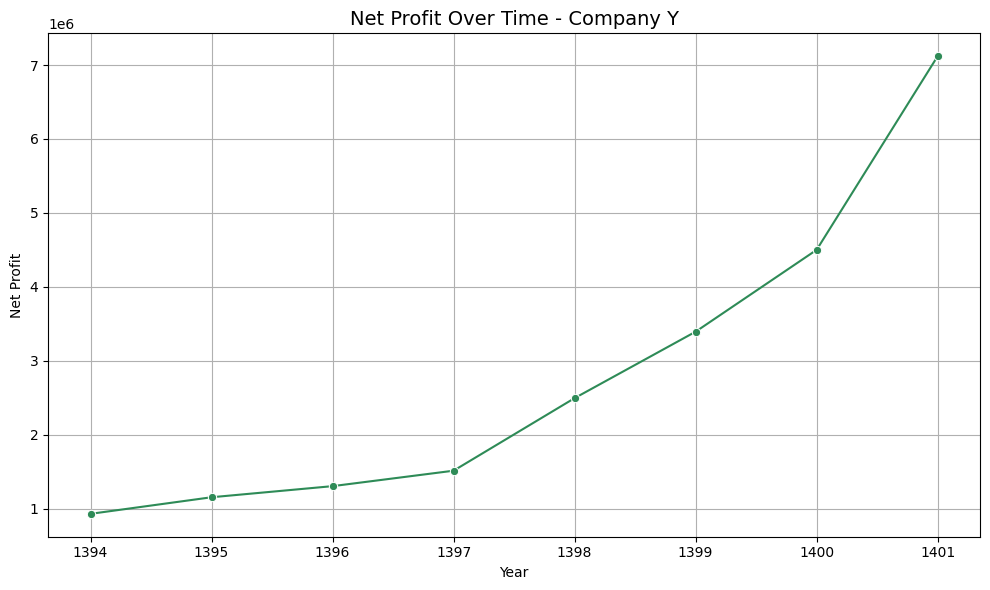

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=company_df, x='Year', y='net_profit', marker='o', color='seagreen')
plt.title(f'Net Profit Over Time - {company_en}', fontsize=14)
plt.xlabel("Year")
plt.ylabel("Net Profit")
plt.grid(True)
plt.tight_layout()
plt.savefig(f'net_profit_{company_en}.png', dpi=300, bbox_inches='tight')
plt.show()

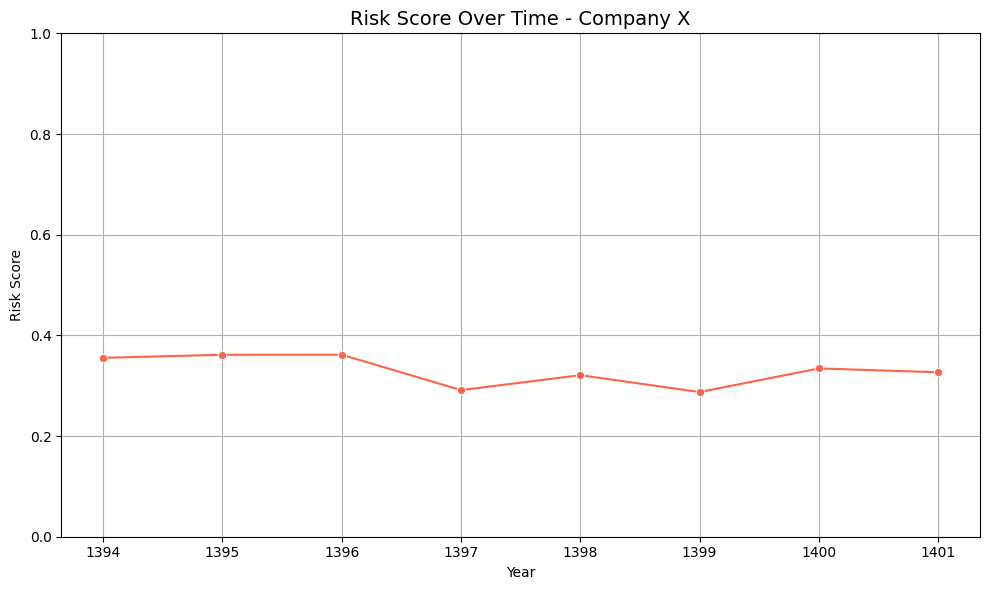

In [ ]:
company_fa = 'ایران خودرو'
company_en = 'Company X'
company_df = merged_df[merged_df['Firm'] == company_fa].sort_values('Year')

plt.figure(figsize=(10, 6))
sns.lineplot(data=company_df, x='Year', y='risk_score', marker='o', color='tomato')
plt.title(f'Risk Score Over Time - {company_en}', fontsize=14)
plt.xlabel("Year")
plt.ylabel("Risk Score")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.savefig(f'risk_score_{company_en}.png', dpi=300, bbox_inches='tight')
plt.show()

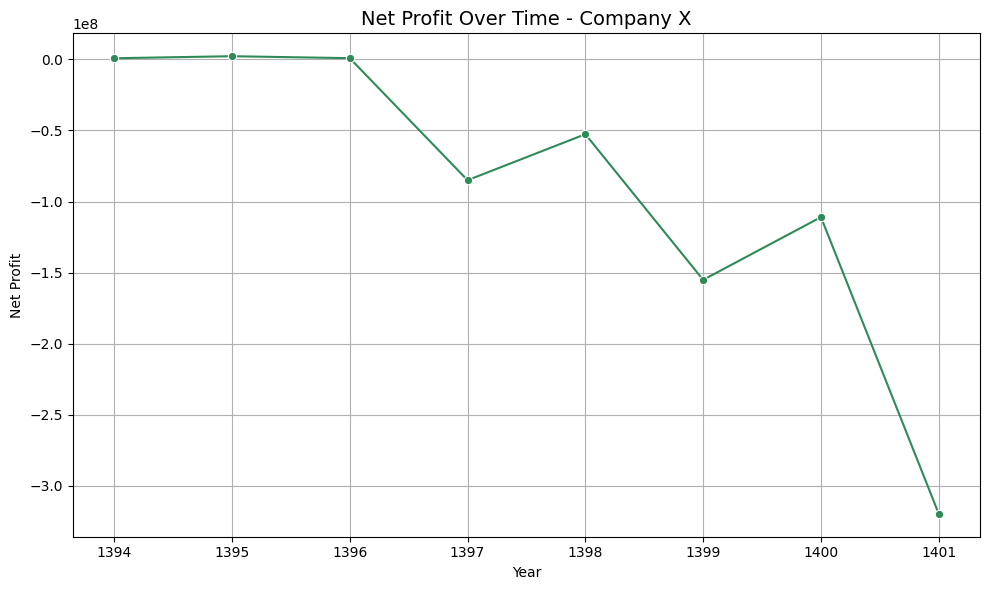

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=company_df, x='Year', y='net_profit', marker='o', color='seagreen')
plt.title(f'Net Profit Over Time - {company_en}', fontsize=14)
plt.xlabel("Year")
plt.ylabel("Net Profit")
plt.grid(True)
plt.tight_layout()
plt.savefig(f'net_profit_{company_en}.png', dpi=300, bbox_inches='tight')
plt.show()

FINISH PROGECT1

# محاسبه ماتریس همبستگی

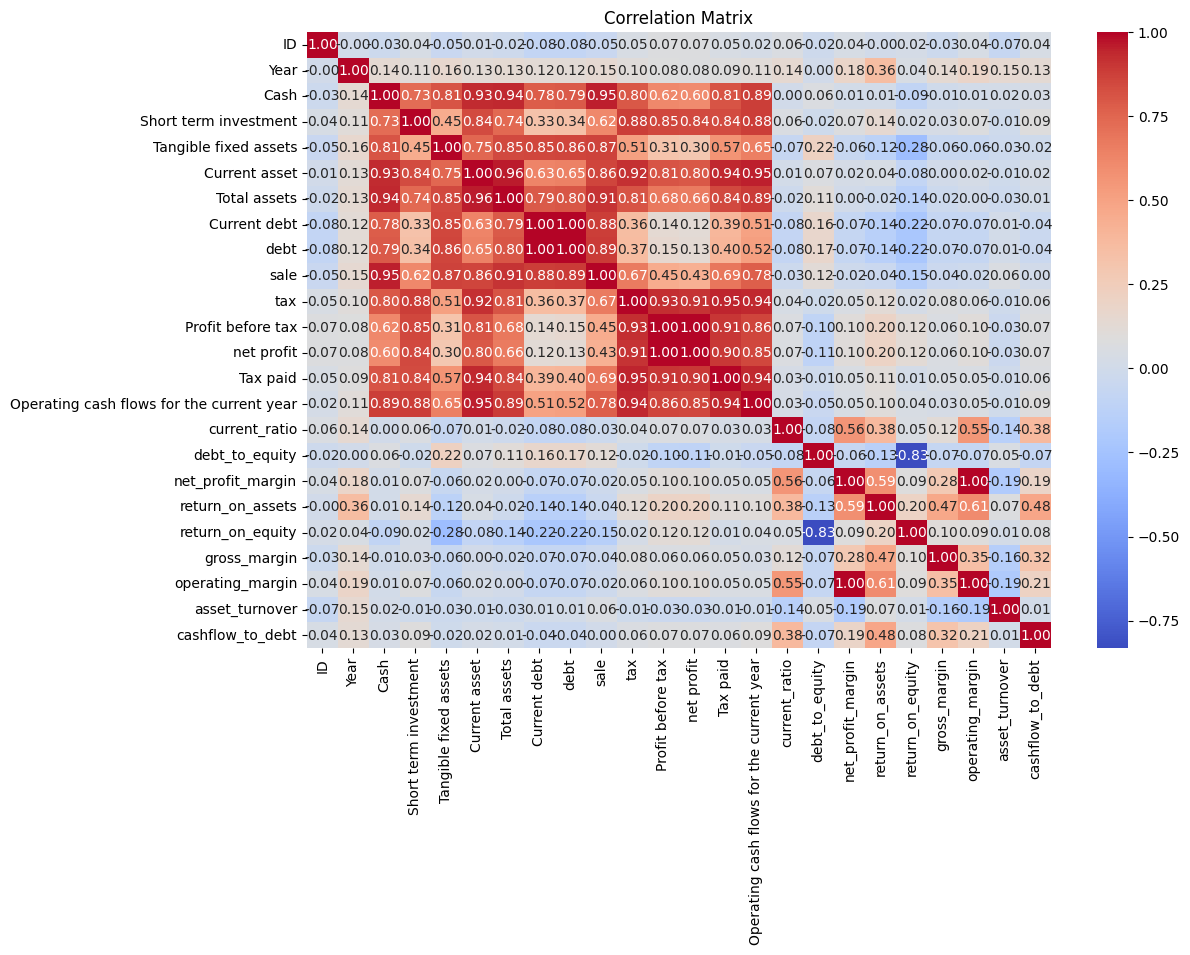

In [ ]:
import pandas as pd
import seaborn as sns

numeric_df = df.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


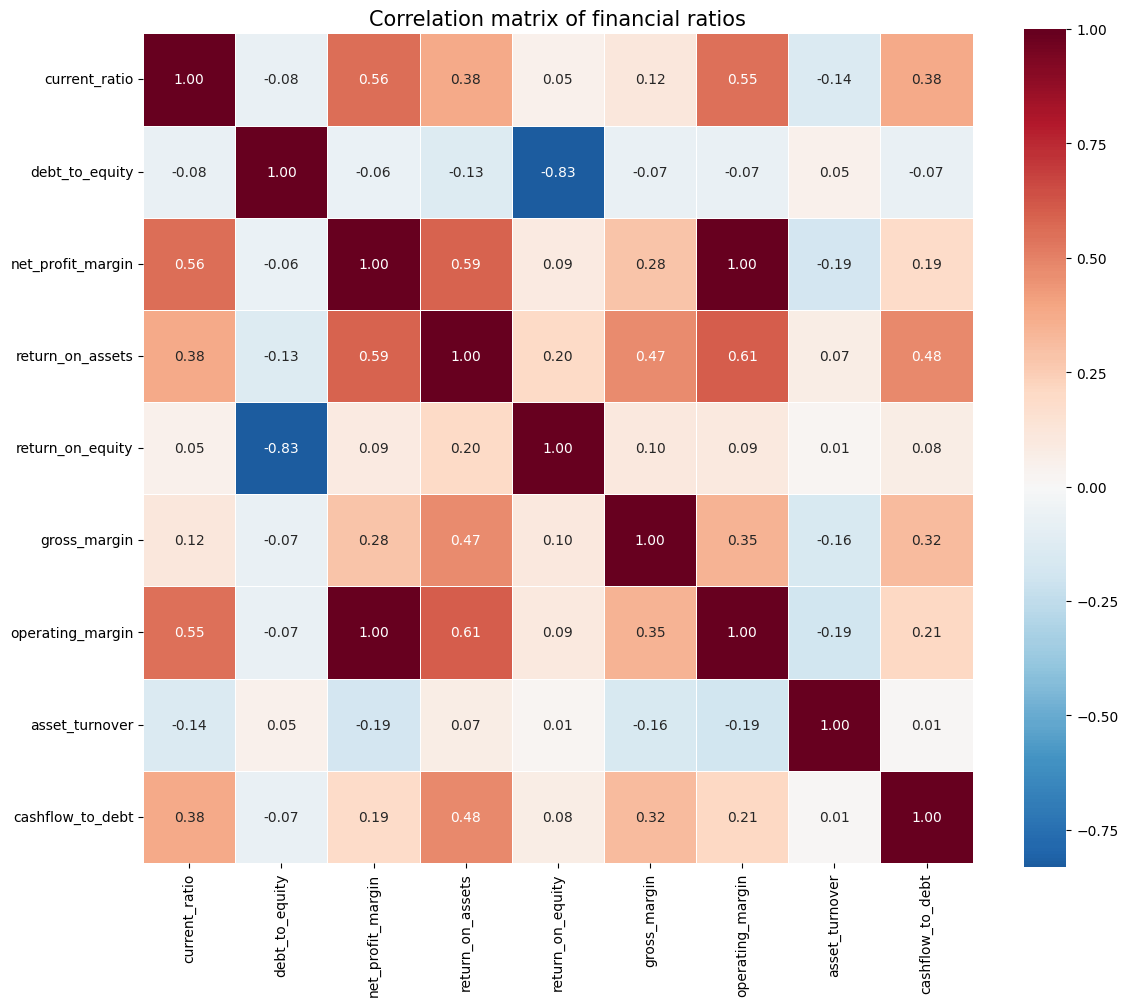

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. لیست تمام نسبت‌های مالی که محاسبه کردید
financial_ratio_columns = [
    'current_ratio', 'debt_to_equity', 'net_profit_margin',
    'return_on_assets', 'return_on_equity', 'gross_margin',
    'operating_margin', 'asset_turnover', 'cashflow_to_debt'
]

# 2. ایجاد یک DataFrame جدید که فقط شامل همین نسبت‌ها باشد
# (با استفاده از .filter() فقط ستون‌هایی که نامشان در لیست بالا هست رو برمی‌داریم)
ratio_df = df.filter(financial_ratio_columns)

# 3. حذف سطرهایی که دارای مقدار NaN هستند (اگر وجود دارند)
ratio_df = ratio_df.dropna()

# 4. محاسبه ماتریس همبستگی
correlation_matrix = ratio_df.corr()

# 5. رسم Heatmap
plt.figure(figsize=(12, 10)) # اندازه نمودار را بزرگ می‌گیریم تا اعداد خوانا باشند
sns.heatmap(correlation_matrix,
            annot=True,    # اعداد درون خانه‌ها نمایش داده شوند
            cmap='RdBu_r', # یک نقشه رنگی خوب برای همبستگی (آبی-قرمز)
            fmt=".2f",     # اعداد تا دو رقم اعشار نشان داده شوند
            center=0,      # مرکز طیف رنگ روی صفر باشد
            square=True,   # خانه‌ها مربعی باشند
            linewidths=.5) # خطوط بین خانه‌ها نازک باشند

plt.title('Correlation matrix of financial ratios', fontsize=15)
plt.tight_layout() # از بریده شدن لیبل‌ها جلوگیری می‌کند
plt.show()

# منطق فازی

In [ ]:
# نصب کتابخانه‌های اصلی
!pip install scikit-fuzzy
!pip install tensorflow
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install pandas
!pip install numpy

# برای نمایش بهتر نمودارها در Colab
!pip install ipython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.4 MB/s eta 0:00:00


شروع استنتاج فازی

In [ ]:
df_result.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1040 entries, 0 to 1039
Data columns (total 29 columns):
 #   Column                                     Non-Null Count  Dtype   
---  ------                                     --------------  -----   
 0   ID                                         1040 non-null   int64   
 1   Firm                                       1040 non-null   object  
 2   Year                                       1040 non-null   int64   
 3   Industry                                   1040 non-null   object  
 4   Symbol                                     1040 non-null   object  
 5   Cash                                       1040 non-null   int64   
 6   Short term investment                      1040 non-null   int64   
 7   Tangible fixed assets                      1040 non-null   int64   
 8   Current asset                              1040 non-null   int64   
 9   Total assets                               1040 non-null   int64   
 10  Current debt     

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import pandas as pd
import matplotlib.pyplot as plt

# خواندن دیتاست
df = pd.read_csv("final_risk_scored_companies.csv")

print("📊 بررسی دقیق‌تر مقادیر متغیرها:")
print(df[['risk_score', 'debt_to_equity', 'net_profit_margin', 'cashflow_to_debt']].describe())

# بررسی مقادیر منفی و غیرعادی
print(f"\n🔍 اطلاعات اضافی:")
print(f"تعداد شرکت‌های با net_profit_margin منفی: {(df['net_profit_margin'] < 0).sum()}")
print(f"تعداد شرکت‌های با debt_to_equity منفی: {(df['debt_to_equity'] < 0).sum()}")
print(f"محدوده risk_score: {df['risk_score'].min():.3f} تا {df['risk_score'].max():.3f}")

# تعریف متغیرهای ورودی و خروجی با محدوده‌های واقعی‌تر
risk_score = ctrl.Antecedent(np.arange(0, 1.1, 0.01), 'risk_score')  # risk_score بین 0-1 است!
debt_to_equity = ctrl.Antecedent(np.arange(-50, 300, 1), 'debt_to_equity')
net_profit_margin = ctrl.Antecedent(np.arange(-1, 1.1, 0.1), 'net_profit_margin')  # بین -100% تا +100%
cashflow_to_debt = ctrl.Antecedent(np.arange(-1, 1.1, 0.1), 'cashflow_to_debt')
profitability_potential = ctrl.Consequent(np.arange(0, 101, 1), 'profitability_potential')

# توابع عضویت برای risk_score (بین 0-1)
risk_score['کم'] = fuzz.trapmf(risk_score.universe, [0, 0, 0.2, 0.4])
risk_score['متوسط'] = fuzz.trimf(risk_score.universe, [0.3, 0.5, 0.7])
risk_score['بالا'] = fuzz.trapmf(risk_score.universe, [0.6, 0.8, 1.0, 1.0])

# توابع عضویت برای debt_to_equity
debt_to_equity['منفی'] = fuzz.trapmf(debt_to_equity.universe, [-50, -50, -10, 0])
debt_to_equity['بسیار_کم'] = fuzz.trimf(debt_to_equity.universe, [-5, 0, 20])
debt_to_equity['کم'] = fuzz.trimf(debt_to_equity.universe, [10, 40, 70])
debt_to_equity['متوسط'] = fuzz.trimf(debt_to_equity.universe, [50, 80, 110])
debt_to_equity['بالا'] = fuzz.trimf(debt_to_equity.universe, [90, 130, 170])
debt_to_equity['بسیار_بالا'] = fuzz.trapmf(debt_to_equity.universe, [150, 200, 300, 300])

# توابع عضویت برای net_profit_margin (بین -1 تا 1)
net_profit_margin['زیان_شدید'] = fuzz.trapmf(net_profit_margin.universe, [-1, -1, -0.5, -0.2])
net_profit_margin['زیان'] = fuzz.trimf(net_profit_margin.universe, [-0.3, -0.15, 0])
net_profit_margin['نزدیک_صفر'] = fuzz.trimf(net_profit_margin.universe, [-0.1, 0, 0.1])
net_profit_margin['سود_کم'] = fuzz.trimf(net_profit_margin.universe, [0.05, 0.1, 0.2])
net_profit_margin['سود_متوسط'] = fuzz.trimf(net_profit_margin.universe, [0.15, 0.25, 0.4])
net_profit_margin['سود_بالا'] = fuzz.trapmf(net_profit_margin.universe, [0.3, 0.5, 1, 1])

# توابع عضویت برای cashflow_to_debt (بین -1 تا 1)
cashflow_to_debt['منفی_شدید'] = fuzz.trapmf(cashflow_to_debt.universe, [-1, -1, -0.3, -0.1])
cashflow_to_debt['منفی'] = fuzz.trimf(cashflow_to_debt.universe, [-0.2, -0.1, 0])
cashflow_to_debt['نزدیک_صفر'] = fuzz.trimf(cashflow_to_debt.universe, [-0.05, 0, 0.05])
cashflow_to_debt['مثبت_کم'] = fuzz.trimf(cashflow_to_debt.universe, [0.02, 0.1, 0.2])
cashflow_to_debt['مثبت_متوسط'] = fuzz.trimf(cashflow_to_debt.universe, [0.15, 0.3, 0.5])
cashflow_to_debt['مثبت_بالا'] = fuzz.trapmf(cashflow_to_debt.universe, [0.4, 0.6, 1, 1])

# توابع عضویت برای خروجی
profitability_potential['بسیار_ضعیف'] = fuzz.trimf(profitability_potential.universe, [0, 0, 20])
profitability_potential['ضعیف'] = fuzz.trimf(profitability_potential.universe, [15, 30, 45])
profitability_potential['متوسط'] = fuzz.trimf(profitability_potential.universe, [40, 55, 70])
profitability_potential['قوی'] = fuzz.trimf(profitability_potential.universe, [65, 75, 85])
profitability_potential['بسیار_قوی'] = fuzz.trimf(profitability_potential.universe, [80, 90, 100])

# تعریف قواعد فازی کامل‌تر و واقعی‌تر
rules = [
    # بهترین حالت‌ها
    ctrl.Rule(risk_score['کم'] & debt_to_equity['بسیار_کم'] & net_profit_margin['سود_بالا'] & cashflow_to_debt['مثبت_بالا'], profitability_potential['بسیار_قوی']),
    ctrl.Rule(risk_score['کم'] & debt_to_equity['کم'] & net_profit_margin['سود_متوسط'] & cashflow_to_debt['مثبت_بالا'], profitability_potential['قوی']),

    # حالت‌های خوب
    ctrl.Rule(risk_score['کم'] & net_profit_margin['سود_بالا'], profitability_potential['قوی']),
    ctrl.Rule(debt_to_equity['بسیار_کم'] & cashflow_to_debt['مثبت_بالا'], profitability_potential['قوی']),
    ctrl.Rule(risk_score['متوسط'] & net_profit_margin['سود_متوسط'] & cashflow_to_debt['مثبت_متوسط'], profitability_potential['متوسط']),

    # حالت‌های متوسط
    ctrl.Rule(risk_score['متوسط'] & debt_to_equity['متوسط'] & net_profit_margin['سود_کم'], profitability_potential['متوسط']),
    ctrl.Rule(risk_score['کم'] & net_profit_margin['نزدیک_صفر'], profitability_potential['متوسط']),

    # حالت‌های ضعیف (زیان‌ده)
    ctrl.Rule(net_profit_margin['زیان'] | cashflow_to_debt['منفی'], profitability_potential['ضعیف']),
    ctrl.Rule(risk_score['بالا'] & net_profit_margin['زیان'], profitability_potential['ضعیف']),
    ctrl.Rule(debt_to_equity['بالا'] & net_profit_margin['زیان'], profitability_potential['ضعیف']),

    # بدترین حالت‌ها (ورشکستگی)
    ctrl.Rule(net_profit_margin['زیان_شدید'] & cashflow_to_debt['منفی_شدید'], profitability_potential['بسیار_ضعیف']),
    ctrl.Rule(risk_score['بالا'] & debt_to_equity['بسیار_بالا'] & net_profit_margin['زیان_شدید'], profitability_potential['بسیار_ضعیف']),

    # قواعد برای debt_to_equity منفی (ساختار سرمایه غیرعادی)
    ctrl.Rule(debt_to_equity['منفی'] & net_profit_margin['سود_بالا'], profitability_potential['متوسط']),
    ctrl.Rule(debt_to_equity['منفی'] & net_profit_margin['زیان'], profitability_potential['ضعیف']),

    # قواعد fallback
    ctrl.Rule(risk_score['کم'], profitability_potential['متوسط']),  # اگر ریسک کم باشد حداقل متوسط است
    ctrl.Rule(risk_score['بالا'], profitability_potential['ضعیف']), # اگر ریسک بالا باشد حداکثر ضعیف است
]

# ایجاد سیستم فازی
profitability_system = ctrl.ControlSystem(rules)
profitability_evaluator = ctrl.ControlSystemSimulation(profitability_system)

def evaluate_profitability_potential(risk, debt_equity, profit_margin, cashflow_debt):
    """ارزیابی پتانسیل سودآوری شرکت"""
    try:
        profitability_evaluator.input['risk_score'] = max(0, min(1.0, risk))
        profitability_evaluator.input['debt_to_equity'] = max(-50, min(300, debt_equity))
        profitability_evaluator.input['net_profit_margin'] = max(-1, min(1, profit_margin))
        profitability_evaluator.input['cashflow_to_debt'] = max(-1, min(1, cashflow_debt))

        profitability_evaluator.compute()
        score = profitability_evaluator.output['profitability_potential']

        # تفسیر نتیجه
        if score >= 80:
            trend = "بسیار قوی"
        elif score >= 65:
            trend = "قوی"
        elif score >= 40:
            trend = "متوسط"
        elif score >= 15:
            trend = "ضعیف"
        else:
            trend = "بسیار ضعیف"

        return score, trend

    except Exception as e:
        print(f"خطا در محاسبه برای risk={risk:.3f}, debt={debt_equity:.1f}, margin={profit_margin:.3f}, cashflow={cashflow_debt:.3f}: {e}")
        return None, None

# تست روی چند نمونه اول
print("\n🧪 تست روی نمونه‌های اول:")
test_samples = df.head(10)
for index, row in test_samples.iterrows():
    score, trend = evaluate_profitability_potential(
        risk=row['risk_score'],
        debt_equity=row['debt_to_equity'],
        profit_margin=row['net_profit_margin'],
        cashflow_debt=row['cashflow_to_debt']
    )

    if score is not None:
        print(f"{row['Firm']} ({row['Year']}): score={score:.1f}, trend={trend}")
    else:
        print(f"{row['Firm']} ({row['Year']}): محاسبه ناموفق")

# اعمال روی تمام دیتاست
print("\n🔄 در حال ارزیابی تمام شرکت‌ها...")
results = []
success_count = 0

for index, row in df.iterrows():
    score, trend = evaluate_profitability_potential(
        risk=row['risk_score'],
        debt_equity=row['debt_to_equity'],
        profit_margin=row['net_profit_margin'],
        cashflow_debt=row['cashflow_to_debt']
    )

    if score is not None:
        success_count += 1
        results.append({
            'ID': row['ID'],
            'Firm': row['Firm'],
            'Symbol': row['Symbol'],
            'Year': row['Year'],
            'risk_score': row['risk_score'],
            'debt_to_equity': row['debt_to_equity'],
            'net_profit_margin': row['net_profit_margin'],
            'cashflow_to_debt': row['cashflow_to_debt'],
            'net_profit': row['net profit'],
            'profitability_potential_score': score,
            'profitability_potential_trend': trend
        })

print(f"✅ تعداد ارزیابی‌های موفق: {success_count} از {len(df)}")

# ایجاد DataFrame نتایج
if results:
    results_df = pd.DataFrame(results)

    print("\n🎯 نتایج جدید ارزیابی پتانسیل سودآوری:")
    print(results_df.head(10))

    print(f"\n📈 توزیع جدید روندهای سودآوری:")
    trend_counts = results_df['profitability_potential_trend'].value_counts()
    print(trend_counts)

    # تحلیل نتایج
    print(f"\n📊 همبستگی با سود خالص واقعی:")
    correlation = results_df['profitability_potential_score'].corr(results_df['net_profit'])
    print(f"همبستگی امتیاز فازی با سود خالص: {correlation:.3f}")

    # ذخیره نتایج
    results_df.to_csv('fuzzy_profitability_analysis_corrected.csv', index=False, encoding='utf-8-sig')
    print("\n💾 نتایج جدید در فایل 'fuzzy_profitability_analysis_corrected.csv' ذخیره شد.")

    # نمایش نمودار
    plt.figure(figsize=(12, 6))
    trend_counts.sort_index().plot(kind='bar', color=['red', 'orange', 'yellow', 'lightgreen', 'green'])
    plt.title('توزیع جدید پتانسیل سودآوری شرکت‌ها')
    plt.xlabel('سطح پتانسیل سودآوری')
    plt.ylabel('تعداد شرکت‌ها')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("❌ هیچ نتیجه‌ای تولید نشد! نیاز به بررسی بیشتر دارد.")

ModuleNotFoundError: No module named 'skfuzzy'

## برای بخش تکمیلی نتایج به سراغ پایداری ساختار سرمایه خواهیم رفت  در این بخش نوسانات نسبت بدهی به حقوق صاحبان سهام در طول بازه مورد مطالعه بررسی خواهد شد

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
file_path = '/content/drive/My Drive/پروژه کارشناسی/final_risk_scored_companies.csv'
df = pd.read_csv(file_path)
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ID       Firm  Year     Industry Symbol    Cash  Short term investment  \
0   1  البرزدارو  1394  مواد دارویی  دالبر   24669                      0   
1   1  البرزدارو  1395  مواد دارویی  دالبر  182875                      0   
2   1  البرزدارو  1396  مواد دارویی  دالبر   22583                      0   
3   1  البرزدارو  1397  مواد دارویی  دالبر  212555                      0   
4   1  البرزدارو  1398  مواد دارویی  دالبر  174887                      0   

   Tangible fixed assets  Current asset  Total assets  ...  debt_to_equity  \
0                 271878        2555666       2852280  ...        0.684945   
1                 330917        3477074       3914815  ...        0.727128   
2                 468898        4806150       5284110  ...        0.933604   
3                 909434        6862026       8361010  ...        1.132759   
4                1

In [ ]:
!pip install -U scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 9.5 MB/s eta 0:00:00


# تحلیل زمانی

In [ ]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.3/978.3 kB 12.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

df = pd.read_excel(file_path)

profit_col = 'net profit'

firms = df['Firm'].unique()

summary_results = []

for firm in firms:
    # فیلتر داده‌ها برای هر شرکت و مرتب‌سازی بر اساس سال
    df_company = df[df['Firm'] == firm].sort_values(by='Year').copy()

    # محاسبه بازده سالانه (درصد تغییر سود خالص)
    df_company['Return'] = df_company[profit_col].pct_change()
    returns = df_company['Return'].dropna()

    # بررسی کافی بودن داده‌ها
    if len(returns) < 6:
        print(f"Insufficient data for {firm}, skipping...")
        continue

    # مقیاس‌بندی مناسب داده‌ها (تقسیم بر 1000 برای بازه مطلوب)
    scaled_returns = returns / 1000

    # مدل‌سازی GARCH(1,1) بدون هشدار مقیاس (rescale=False)
    model = arch_model(scaled_returns, vol='Garch', p=1, q=1, rescale=False)
    garch_res = model.fit(disp='off')

    # ذخیره پارامترها و اطلاعات مدل در لیست نتایج
    summary_results.append({
        'Firm': firm,
        'alpha': garch_res.params.get('alpha[1]', None),
        'beta': garch_res.params.get('beta[1]', None),
        'omega': garch_res.params.get('omega', None),
        'AIC': garch_res.aic
    })

    # (اختیاری) نمایش خلاصه مدل برای هر شرکت
    print(f"\nGARCH model results for {firm}:")
    print(garch_res.summary())

    # (اختیاری) رسم نمودار نوسانات شرطی تخمین زده شده
    plt.figure(figsize=(10,4))
    plt.plot(garch_res.conditional_volatility)
    plt.title(f'Conditional Volatility - {firm}')
    plt.xlabel('Time')
    plt.ylabel('Volatility')
    plt.grid(True)
    plt.show()

# تبدیل نتایج به DataFrame و نمایش خلاصه
results_df = pd.DataFrame(summary_results)
print("\nSummary of GARCH model parameters for all firms:")
print(results_df)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# محاسبه سود یا بازده سالانه یک شرکت
# df_company: DataFrame فیلترشده برای یک شرکت خاص با ستون 'Year' و 'net profit'
df_company['Return'] = df_company['net profit'].pct_change()

# محاسبه میانگین متحرک ۳ ساله و انحراف معیار متحرک
df_company['SMA_3'] = df_company['Return'].rolling(3).mean()
df_company['STD_3'] = df_company['Return'].rolling(3).std()

# رسم نمودار
plt.figure(figsize=(10,5))
plt.plot(df_company['Year'], df_company['Return'], label='Annual Return')
plt.plot(df_company['Year'], df_company['SMA_3'], label='3-Year Moving Average')
plt.plot(df_company['Year'], df_company['STD_3'], label='3-Year Moving StdDev')
plt.legend()
plt.show()

In [ ]:
# مرتب سازی نزولی بر اساس نوسان نسبت بدهی به حقوق صاحبان سهام
top20_volatility = df.sort_values(by='debt_to_equity', ascending=False).head(20)

# نمایش این 20 شرکت و مقدار نوسانشون
print(top20_volatility)

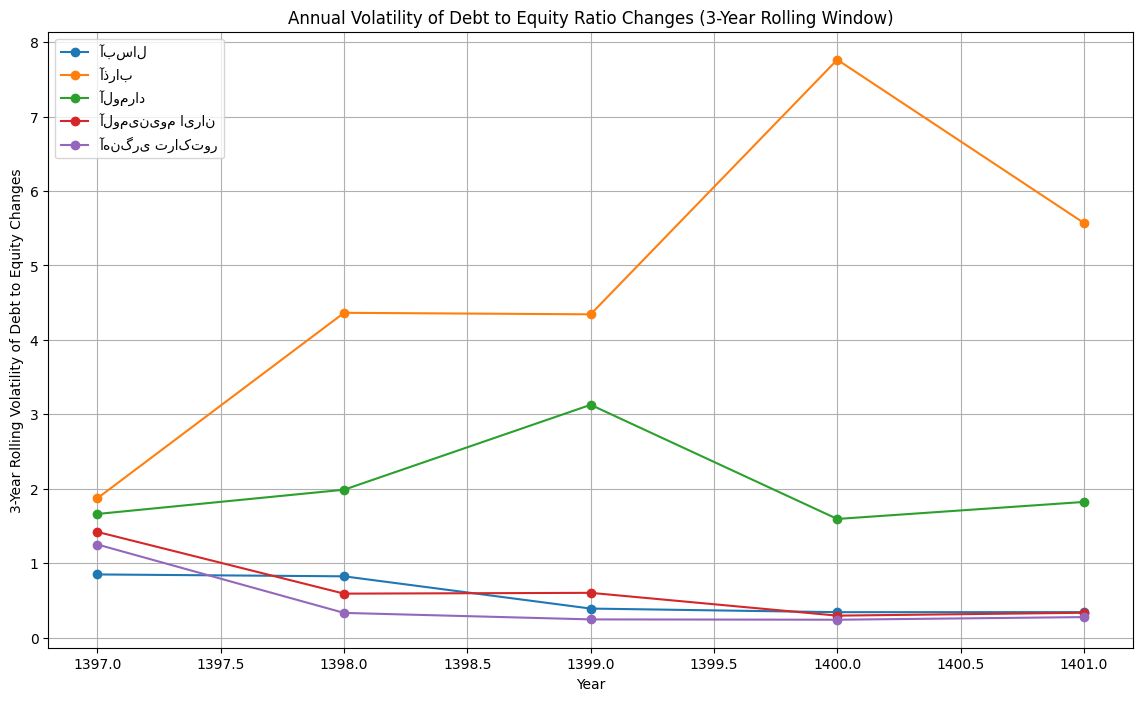

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assume df is your DataFrame with columns ['company', 'year', 'debt', 'equity']

# 1. Calculate Debt to Equity Ratio

# 2. Sort by company and year
df = df.sort_values(['Firm', 'Year'])

# 3. Calculate yearly changes of Debt to Equity Ratio per company
df['dte_diff'] = df.groupby('Firm')['debt_to_equity'].diff()

# 4. To calculate annual volatility of these changes:
#    Since each company has one value per year, volatility per single year isn't meaningful.
#    Instead, calculate rolling volatility over a window (e.g., 3 years).

# 5. Calculate rolling 3-year standard deviation of the changes per company
df['volatility_3yr'] = df.groupby('Firm')['dte_diff'].rolling(window=3).std().reset_index(level=0, drop=True)

# 6. Plot volatility for a sample of companies
sample_companies = df['Firm'].unique()[:5]  # first 5 companies as a sample

plt.figure(figsize=(14,8))
for company in sample_companies:
    data = df[df['Firm'] == company]
    plt.plot(data['Year'], data['volatility_3yr'], marker='o', label=company)

plt.xlabel('Year')
plt.ylabel('3-Year Rolling Volatility of Debt to Equity Changes')
plt.title('Annual Volatility of Debt to Equity Ratio Changes (3-Year Rolling Window)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd

# فرض بر اینکه df دیتافریم اصلی شماست و ستون‌های زیر در آن موجود است:
# 'Firm' - نام شرکت
# 'Year' - سال مالی
# 'debt' - میزان بدهی
# 'Total assets' - کل دارایی‌ها

# محاسبه نسبت بدهی به حقوق صاحبان سهام
df['debt_to_equity'] = df['debt'] / (df['Total assets'] - df['debt'])

# لیست همه شرکت‌های موجود
all_firms = df['Firm'].unique()

results = []

for firm in all_firms:
    sub = df[df['Firm'] == firm].sort_values('Year').copy()

    # حداقل 4 داده برای محاسبه rolling لازم است
    if len(sub) < 4:
        results.append({
            'Company': firm,
            'MeanRollingVol': None,
            'StdVol': None,
            'MaxVol': None,
            'MinVol': None
        })
        continue

    sub['D_E_diff'] = sub['Debt_to_Equity'].diff()
    rolling_vol = sub['D_E_diff'].rolling(window=3).std()

    results.append({
        'Company': firm,
        'MeanRollingVol': rolling_vol.mean(),
        'StdVol': rolling_vol.std(),
        'MaxVol': rolling_vol.max(),
        'MinVol': rolling_vol.min()
    })

# تبدیل نتایج به DataFrame و نمایش
stats_df = pd.DataFrame(results)

import pandas as pd

# تنظیم برای نمایش همه ردیف‌ها در خروجی
pd.set_option('display.max_rows', None)

stats_df

,Company,MeanRollingVol,StdVol,MaxVol,MinVol
0,آبسال,0.548539,0.262758,0.848027,0.340945
1,آذراب,4.783679,2.142150,7.765447,1.872806
2,آلومراد,2.038241,0.627687,3.127596,1.593777
3,آلومینیوم ایران,0.647519,0.454115,1.419389,0.294284
4,آهنگری تراکتور,0.467853,0.438779,1.250031,0.239485
5,البرزدارو,0.114507,0.058053,0.185923,0.040284
6,الکتریک خودرو شرق,2.825843,1.882558,4.573269,0.641530
7,اما,0.131490,0.090934,0.272718,0.051874
8,ایران تایر,3.951584,4.725550,12.302353,0.954411
9,ایران ترانسفو,0.927024,0.108109,1.091999,0.789052
